# 0. EDA Process

**1. 1차원데이터분석**

**1.** **변수종류파악( 수치형/ 범주형/ 시간형)**

**2.** **변수종류별분석지표( 수치형/ 범주형/ 시간형)**

**3.** **시각화**

- **도수분포표/ 히스토그램/ 상자그림**

**2. 2차원데이터분석**

**1.** **공분산/ 상관계수**

**2.** **다중공선성확인**

**3.** **시각화**

- **산점도/ 회귀직선/ 히트맵**

In [11]:
import pandas as pd
import numpy as np

## 1. 항공사 지연요인 EDA

출처 : https://www.kaggle.com/datasets/pitterman/airline-stats

- 항공사 한 편당 지연 퍼센트

In [105]:
# 범주형 변수 : airline
# 수치형 변수 : carrier_dely, atc_delay, weather_delay
df = pd.read_csv('./data/airline_stats.csv')
df.head() 

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


In [35]:
# 항공사 명만 출력
print(df.airline.unique())

['American' 'Alaska' 'Jet Blue' 'Delta' 'United' 'Southwest']


In [36]:
# 항공사 명과 수를 출력 
# 총 6개 항공사의 데이터를 포함하고 있었고 Delta가 9107건으로 가장 많았다. 
print(df.airline.value_counts())

Delta        9107
American     5725
Southwest    5584
United       5426
Alaska       3851
Jet Blue     3775
Name: airline, dtype: int64


### - 수치형 변수의 통계량 확인

In [37]:
df.describe()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay
count,33440.000000,33440.000000,33440.000000
mean,7.041475,5.089962,0.684776
std,4.497596,4.718647,1.073743
min,0.000000,0.000000,0.000000
25%,4.145455,2.146565,0.000000
50%,6.356893,3.900000,0.316002
75%,9.140474,6.630238,0.935161
max,100.000000,100.000000,33.333333


항공사 측 지연 요인으로 보았을 때  American이 평균 9.04 % Jet Blue 8.08% 으로 나타났다. 

표준편차가 큰 항공사는 표준값이 5.36인 United 항공사이다.  

In [49]:
#항공사별 기술통계량 확인
#df.groupby('airline').describe()
df.groupby('airline')['pct_carrier_delay'].describe()

,count,mean,std,min,25%,50%,75%,max
airline,,,,,,,,
Alaska,3851.0,3.521889,2.483224,0.0,1.935484,3.225806,4.685599,22.290323
American,5723.0,9.042180,4.139067,0.0,6.338538,8.428571,10.988763,50.000000
Delta,9095.0,6.333460,4.695292,0.0,3.813989,5.548387,7.821952,100.000000
Jet Blue,3773.0,8.081843,3.797737,0.0,5.341176,7.657895,10.280000,28.000000
Southwest,5584.0,7.521997,3.345085,0.0,5.070294,6.960930,9.354839,24.800000
United,5414.0,7.398833,5.369283,0.0,4.034708,6.445210,9.633110,100.000000


### - 결측치 확인

In [97]:
# 각 변수 별 결측치가 28개씩 존재 
df.isnull().sum()

pct_carrier_delay    28
pct_atc_delay        28
pct_weather_delay    28
airline               0
dtype: int64

### - 시각화 

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

지연요인별 도수가 차이가 있음. <br>
항공사지연요인은 첫번째 구간이 12천, 두번째구간이 15천 이다. <br>
ATC 지연요인은 첫번째 구간이 2만으로 가장 높다. <br>
날씨 지연요인은 첫번째 구간이 3만으로 다른 요인들에 비해 높다.


Text(0.5, 1.0, 'weather_delay')

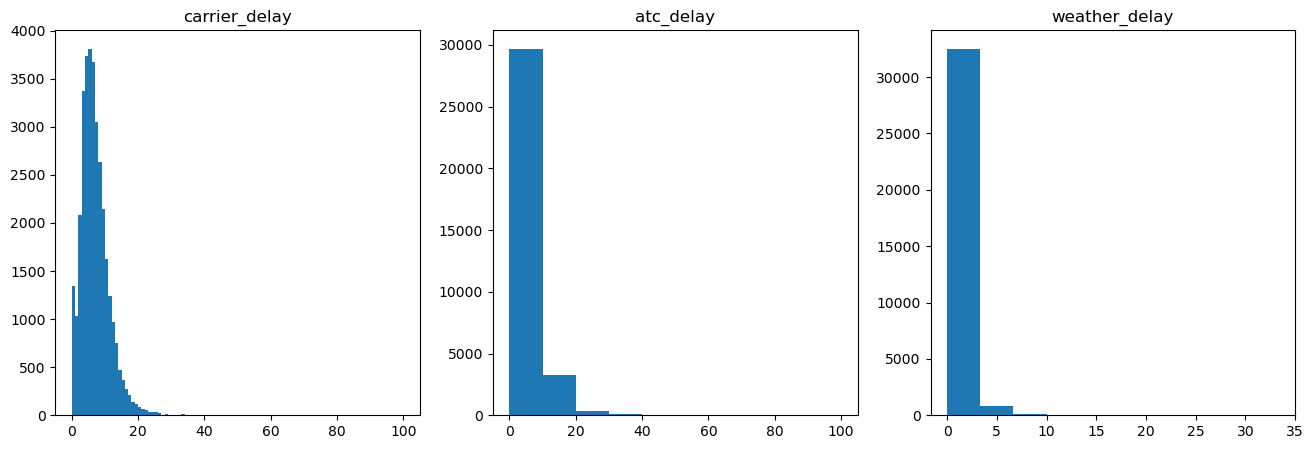

In [66]:
fig = plt.figure(figsize=(16,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.hist(df.pct_carrier_delay, bins=100)
ax2.hist(df.pct_atc_delay)
ax3.hist(df.pct_weather_delay)

ax1.set_title('carrier_delay')
ax2.set_title('atc_delay')
ax3.set_title('weather_delay')

지연 유형별 중앙값, 사분위수, 이상치를 확인

1) 항공사 지연: 20% 이상인 경우를 이상치로 판단, 그런데 100%에 육박하는 극단적인 지연율도 있다. 
2) ATC 지연: 항공사 지연보다 낮은 수준에서 이상치로 판단, 이도 역시 100%인 극단적인 사례가 있다.
3) 날씨 지연: 중앙값, IQR 자체가 작다. 

<AxesSubplot:>

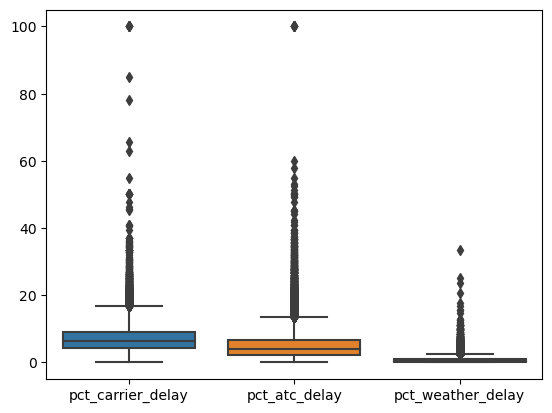

In [70]:
sns.boxplot(data=df)

<AxesSubplot:xlabel='airline', ylabel='pct_carrier_delay'>

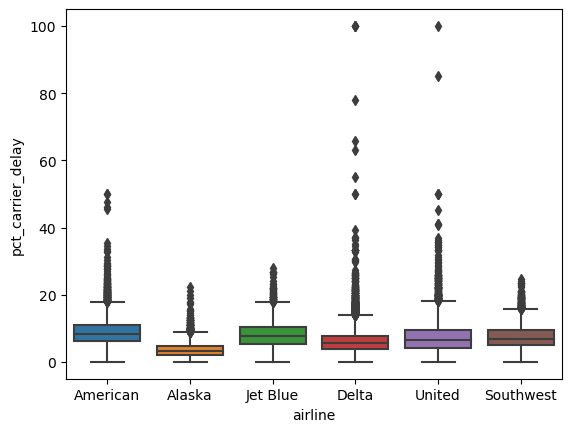

In [85]:
#항공사별 boxplot 

sns.boxplot(data=df, x='airline', y='pct_carrier_delay')

<AxesSubplot:xlabel='airline', ylabel='pct_atc_delay'>

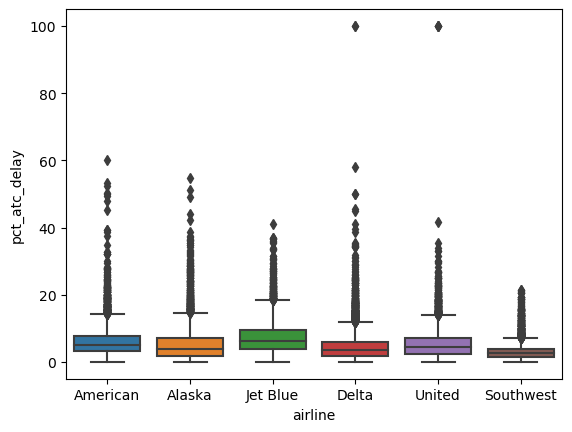

In [84]:
sns.boxplot(data=df, x='airline', y='pct_atc_delay')

<AxesSubplot:xlabel='airline', ylabel='pct_weather_delay'>

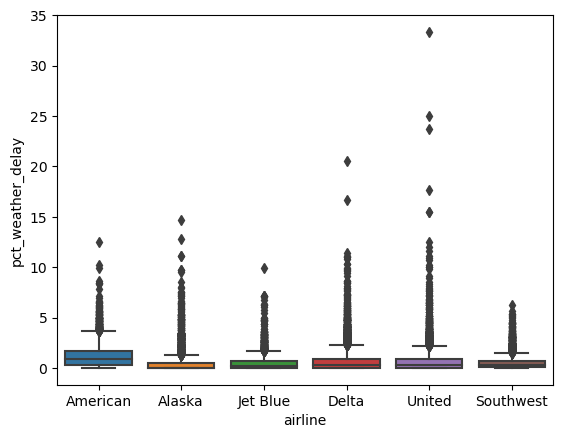

In [86]:
sns.boxplot(data=df, x='airline', y='pct_weather_delay')

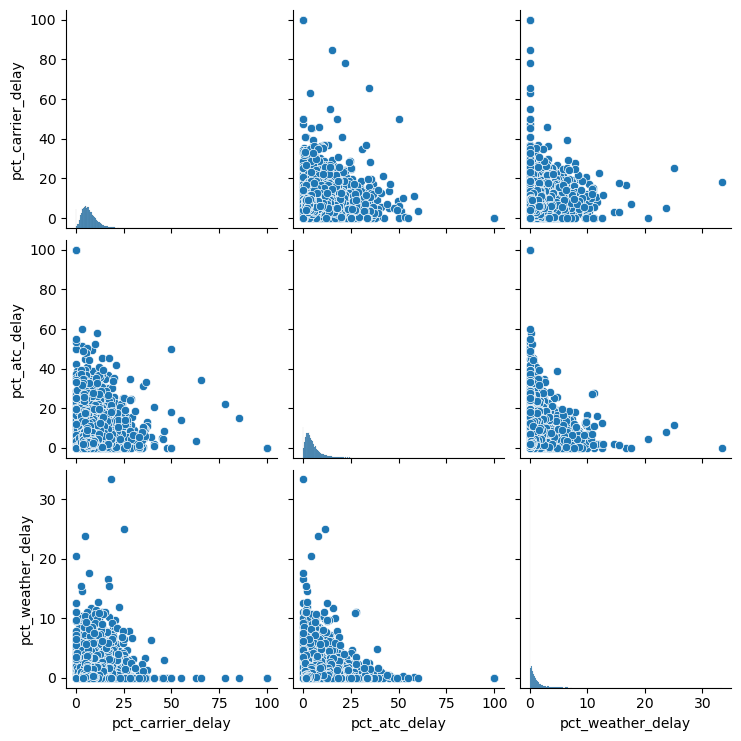

In [87]:
sns.pairplot(df)

In [88]:
# 상관관계 시각화

In [94]:
cor_matrix = df.corr()
cor_matrix

,pct_carrier_delay,pct_atc_delay,pct_weather_delay
pct_carrier_delay,1.000000,0.144474,0.161474
pct_atc_delay,0.144474,1.000000,0.091729
pct_weather_delay,0.161474,0.091729,1.000000


<AxesSubplot:>

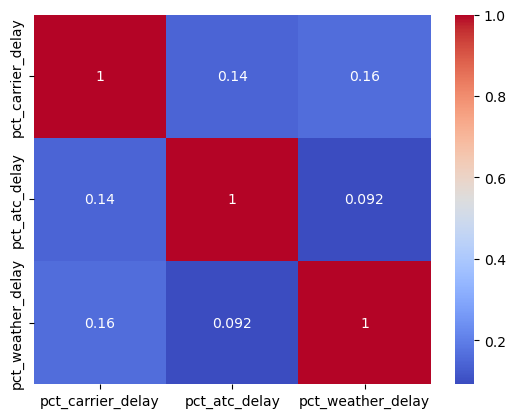

In [96]:
sns.heatmap(cor_matrix, annot=True , cmap = 'coolwarm')

### - 결측치 처리

In [98]:
df.isnull().sum()

pct_carrier_delay    28
pct_atc_delay        28
pct_weather_delay    28
airline               0
dtype: int64

In [99]:
df_cleaned = df.dropna()
df_cleaned

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American
...,...,...,...,...
33463,6.186422,8.798491,1.651940,Southwest
33464,9.522167,3.591133,0.261084,Southwest
33465,9.164179,2.664179,0.343284,Southwest
33466,5.152293,1.964520,0.122817,Southwest


In [101]:
df_cleaned.to_csv('df_cleaned.csv', index=False)

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American
...,...,...,...,...
33463,6.186422,8.798491,1.651940,Southwest
33464,9.522167,3.591133,0.261084,Southwest
33465,9.164179,2.664179,0.343284,Southwest
33466,5.152293,1.964520,0.122817,Southwest


In [103]:
df_cleaned.isnull().sum()

pct_carrier_delay    0
pct_atc_delay        0
pct_weather_delay    0
airline              0
dtype: int64